Ejercicios

EJ 1: norma 1
Desarrolle
a. Una función norma(x,p) que reciba un vector x (un objeto iterable) y una
norma p y retorne su norma.
b. Una función normaliza(X,p) que reciba una lista de vectores X y una norma p y retorne una lista Y donde cada elemento corresponde a normalizar los elementos de X con la norma p.
Emplee la función construida para graficar, en un mismo plot, los vectores con norma 1 de R2 según las normas p = 1,2,5,10,100,200. Describa las figuras que observa. Identifique a qué forma funcional converge la norma para valores de p −→+∞. Muestre gráficamente que ese límite puede expresarse con la norma infinito

In [ ]:
#Mision cumplida
def norma(x,p):
    norm = 0
    if p == "inf":
        for elem in x:
            if abs(elem) > norm:
                norm = abs(elem)
    else:
        suma = 0
        for elem in x:
            suma += abs(elem)**p
            norm = suma**(1/p)
    return norm

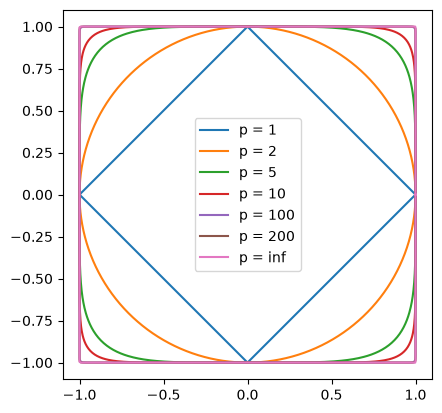

In [10]:
#Mision cumplida
import numpy as np
def norma(x,p):
    norm = 0
    if p == "inf":
        for elem in x:
            if abs(elem) > norm:
                norm = abs(elem)
    else:
        suma = 0
        for elem in x:
            suma += abs(elem)**p
            norm = suma**(1/p)
    return norm

def normaliza(X,p):
    normas = []
    for i in range(len(X)):
        vector = X[i].astype(float).copy()
        for j in range(len(vector)):
            vector[j] = vector[j]/norma(X[i],p)
        normas.append(vector)
    return normas

'''
h = np.ones((1,5))
print(norma(h[0],2))
print(normaliza(h,2)[0])
print(norma(normaliza(h,2)[0],1))'''

import matplotlib.pyplot as plt
angulos = np.linspace(0,2*np.pi,1000)
X = np.array([[np.cos(a),np.sin(a)] for a in angulos])

normas_p = [1,2,5,10,100,200,"inf"]

for p in normas_p:
    normalizados = normaliza(X,p)
    coord_x = [v[0] for v in normalizados]
    coord_y = [v[1] for v in normalizados]
    plt.plot(coord_x, coord_y, label=f"p = {p}")

plt.gca().set_aspect('equal')
plt.legend()

EJ 2: Normas q,p
desarrollaremos funciones aleatorias y exactas para calcular las normas inducidas de la matriz
a. Aplicamos el método de Monte Carlo para estimar la norma inducida de una matriz. Para ello, implementar una función normaMatMC(A,q,p,Np) que estime ||A||q,p numéricamente, usando Np vectores x de Rn generados al azar. La función debe retornar la norma ||A||q,p y el vector x en el cual se alcanza el máximo.
b. Use la función construida para estimar las siguientes normas, junto a las posiciones en las que se alcanzan:

In [11]:
def normaMatMC(A,q,p,Np):
    angulos = np.linspace(0,2*np.pi,Np)
    vectores = np.array([[np.cos(a),np.sin(a)] for a in angulos])
    normalizados = normaliza(vectores,p)
    max = []
    norm = 0
    for vector in normalizados:
        norma_matriz = norma(A@vector,q)
        if norma_matriz > norm:
            norm = norma_matriz
            max = vector
    return norm,max


print(normaMatMC(A=np.eye(2),q=2,p=1,Np=1000))
print(normaMatMC(np.eye(2),1,2,1000))
print(normaMatMC(np.eye(2),2,"inf",1000))
print(normaMatMC(np.eye(2),"inf",2,1000))
print(normaMatMC([[0,-1],[1,0]],2,2,1000))
print(normaMatMC([[1,0],[0,0]],2,2,1000))
print(normaMatMC([[1,0],[0,0]],"inf","inf",1000))
print(normaMatMC([[10,10],[0,0]],2,"inf",1000))


(np.float64(1.0), array([1., 0.]))
(np.float64(1.4142131253204369), array([0.70655065, 0.70766248]))
(np.float64(1.4131030397054314), array([0.99842887, 1.        ]))
(np.float64(1.0), array([1., 0.]))
(np.float64(1.0), array([1., 0.]))
(np.float64(1.0), array([1., 0.]))
(np.float64(1.0), array([1., 0.]))
(np.float64(19.984288661816272), array([0.99842887, 1.        ]))


Construya una función normaExacta(A,p=[1,’inf’]) que calcule las normas 1 e ∞ de una matriz A usando las expresiones
y comparelas con lo obtenido en el punto anterior. Nota: cuando las normas de partida y llegada son las mismas (p = q) la norma ||A||p,p de nota simplemente ||A||p

In [ ]:
#opcion 1
def normaExacta(A,p=[1,"inf"]):
    if isinstance(p,int):
        if p == 1:
            norm = 0
            for j in range(len(A[0])):
                norma_columna = 0
                for i in range(len(A)):
                    norma_columna += abs(A[i][j])
                if norma_columna > norm:
                    norm = norma_columna
        else:
            norm = None
    elif isinstance(p,str):
        if p == "inf":
            norm = 0
            for fila in A:
                norma_fila = norma(fila,1)
                if norma_fila > norm:
                    norm = norma_fila
        else:
            norm = None
    else:
        if p[0] == 1:
            norm = [normaExacta(A,1),normaExacta(A,"inf")]
        else:
            norm = None
    return norm

In [ ]:
#opcion 2 (usando traspuesta)
def traspuesta(A):
    f,c = A.shape
    T = np.zeros((c,f))
    i = 0
    while i < f:
        T[i:,:] = A[:,i]
        i+=1
    return T

def normaExacta(A,p=[1,"inf"]):
    if isinstance(p,int):
        if p == 1:
            A_traspuesta = traspuesta(A)
            norm = normaExacta(A_traspuesta,"inf")
        else:
            norm = None
    elif isinstance(p,str):
        if p == "inf":
            norm = 0
            for fila in A:
                norma_fila = norma(fila,1)
                if norma_fila > norm:
                    norm = norma_fila
        else:
            norm = None
    else:
        if p[0] == 1:
            norm = [normaExacta(A,1),normaExacta(A,"inf")]
        else:
            norm = None
    return norm

EJ 3: Número de condición
a. condMC(A,p) que estime el número de condición de A usando la norma inducida p. La función debe emplear la función normaMatMC desarrollada anteriormente1.
inversa de A: np.linalg.inv(A)
κp(A) = ||A||p ||A−1||p

In [ ]:
#en el modulo se entrega asi (en los tests archivo toma Np como parametro)
def condMC(A,p):
    A_inversa = np.linalg.inv(A)
    nro_cond = normaMatMC(A,p,p,1000)[0]*normaMatMC(A_inversa,p,p,1000)[0]
    return nro_cond

b. Desarrolle una rutina para poner a prueba la cota dada por el número de condición. Para esto:
i. Desarrolle una funcion variaPerc(b,perc) que reciba un vector b ∈Rn y varíe sus elementos en un porcentaje aleatorio. Identifique qué norma es más sensible a esta variación. Tip: Una forma de realizar esto es multiplicar cada elemento de b por un número aleatorio entre 1 − perc/100 y 1 + perc/100. De esta forma, tendremos que ||b − ˜b||/||b|| ≤ perc/100.
ii. Construya una función que reciba a una matriz A, una norma p, un porcentaje perc y una cantidad de realizaciones Np y siga el siguiente esquema para encontrar la peor combinación de b y ˜b para la matriz A:
- genera Np instancias de b y Np instancias de ˜b, donde la variación porcentual es a lo sumo perc.
- resuelve Ax = b y A˜x = ˜b.
- Calcula ex = ||x − ˜x||/||x|| y eb = ||b − ˜b||/||b||
- Calcula el número de condición de A.
- Retorna en una lista el número de condición, los 2Np errores de ex y eb, y los valores de b y ˜b en los que se alcanza el máximo de ex

In [ ]:
#Modulo
def condExacta(A,p):
    A_inversa = np.linalg.inv(A)
    nro_cond = normaExacta(A,p)*normaExacta(A_inversa,p)
    return nro_cond